#### 一、用第一次作业的5只股票日收益率和无风险利率数据，按如下方式建立投资策略：
滚动：50天建模、月频调仓

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

In [2]:
# 无风险
rf_list = []
for year in range(2010, 2022):
    df_year = pd.read_excel(
        f"./Data/中国国债收益率_财政部/财政部-中国国债收益率曲线历史数据{year}年01月04日—{year}年12月31日.xlsx",
        na_values=[0]
    )
    rf_list.append(df_year)

df_risk_free = pd.concat(rf_list)
df_risk_free.set_index("日期",inplace=True)
df_risk_free.index = pd.to_datetime(df_risk_free.index)
df_risk_free.sort_index(inplace=True)

rf_day = (1+df_risk_free["1年"]/100)**(1/252)-1
display(rf_day.tail())

日期
2021-12-27    0.000092
2021-12-28    0.000092
2021-12-29    0.000092
2021-12-30    0.000090
2021-12-31    0.000088
Name: 1年, dtype: float64

完成作业的过程中发现，万华化学的数据异常，查询发现2017.12.4-2018.6.4期间，万华化学停牌，所以为了保证交易区间的完整，截取数据到2017.12.4之前

In [3]:
# 股票
stock_data = pd.read_excel("./Data/股票类/沪深300成分股收盘价日数据.xlsx", na_values=[0])

stock = stock_data.copy()
stock.columns = stock.iloc[0]
stock = stock.drop(0)
stock.rename(columns={stock.columns[0]:"日期"},inplace=True)
stock = stock.set_index("日期")
stock.index = pd.to_datetime(stock.index)

stocks = ["工商银行","中国石油","万华化学","保利发展","贵州茅台"]
stock_ret = stock[stocks].pct_change()
stock_ret = stock_ret[stock.index<"2017-12-04"].dropna()
stock_ret = stock_ret.apply(pd.to_numeric)
display(stock_ret.tail())

,工商银行,中国石油,万华化学,保利发展,贵州茅台
日期,,,,,
2017-11-27,-0.014827,-0.007143,-0.016720,0.001675,-0.013888
2017-11-28,-0.010033,-0.015588,0.015655,-0.023411,0.043361
2017-11-29,0.000000,0.003654,0.031624,0.100171,-0.015596
2017-11-30,0.000000,-0.008495,-0.008243,-0.019455,-0.011158
2017-12-01,-0.005068,-0.001224,-0.022857,0.011905,-0.013708


每月最后一个交易日结束后，用之前的50日数据估计：平均收益率向量（5维）、协方差矩阵（5×5）和协方差矩阵的最小特征值；展示最小特征值的序列；

In [4]:
last_dates = stock_ret.index.to_series().resample("ME").max()
avg_rets = pd.DataFrame(index=last_dates,columns=stocks,dtype=float)
rf_mon = pd.Series(index=last_dates,name="无风险",dtype=float)
cov_dic = {}
cov_eigval = pd.Series(index=last_dates,dtype=float)

rf_day_aligned = rf_day.reindex(stock_ret.index).ffill()

for date in last_dates:
    idx = stock_ret.index.get_loc(date)
    if idx < 49:
        continue
    
    window_ret = stock_ret.iloc[idx-49:idx+1]
    window_rf = rf_day_aligned.iloc[idx-49:idx+1]
    
    avg_rets.loc[date] = np.expm1(np.log1p(window_ret).mean())
    rf_mon.loc[date] = np.expm1(np.log1p(window_rf).mean())
    
    cov_matrix = window_ret.cov()
    cov_dic[date] = cov_matrix
    cov_eigval.loc[date] = np.linalg.eigvalsh(cov_matrix).min()

avg_rets.dropna(inplace=True)
rf_mon.dropna(inplace=True)
cov_eigval.dropna(inplace=True)

display(avg_rets.tail())
display(rf_mon.tail())
display(cov_eigval.tail())

,工商银行,中国石油,万华化学,保利发展,贵州茅台
日期,,,,,
2017-08-31,0.003821,0.001064,0.006492,0.001407,0.001064
2017-09-29,0.002371,0.000075,0.005645,-0.001067,0.001797
2017-10-31,0.001676,0.001015,0.001478,0.001928,0.004410
2017-11-30,0.000136,0.000521,-0.001824,0.002145,0.005042
2017-12-01,0.000412,0.000446,-0.001995,0.001806,0.004800


日期
2017-08-31    0.000133
2017-09-29    0.000133
2017-10-31    0.000135
2017-11-30    0.000138
2017-12-01    0.000138
Name: 无风险, dtype: float64

日期
2017-08-31    0.000047
2017-09-29    0.000040
2017-10-31    0.000043
2017-11-30    0.000068
2017-12-01    0.000066
dtype: float64

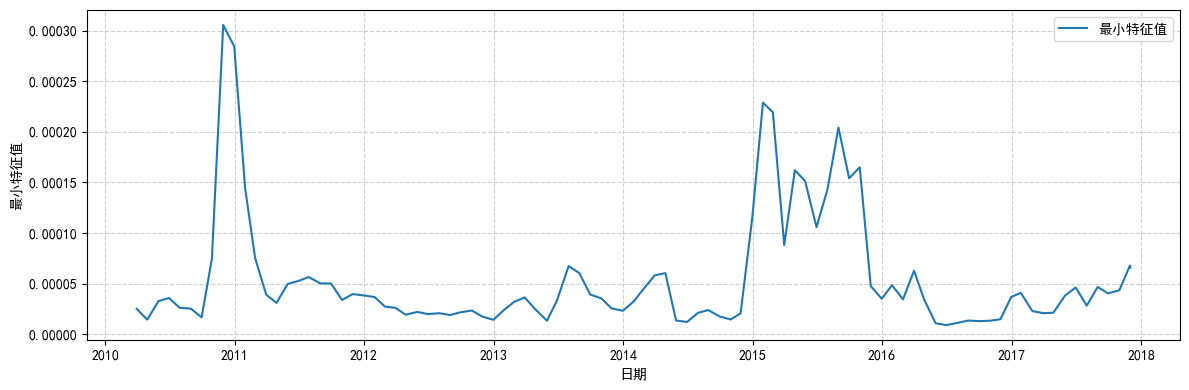

In [5]:
plt.figure(figsize=(12,4))
plt.plot(cov_eigval.index,cov_eigval.values,label="最小特征值")
plt.grid(True,linestyle='--',alpha=0.6)
plt.xlabel("日期")
plt.ylabel("最小特征值")
plt.legend()
plt.tight_layout()
plt.savefig("./Pictures/Hw3_最小特征值时间序列.png") 
plt.show()

计算以下组合的权重并进行配置：
- 全局最小方差组合
- 均值-方差最优组合（均值可选(b)中估计的平均收益率向量的分量或者均值）
- 二次效用最优组合（自选风险厌恶系数）。

In [6]:
import numpy as np
import pandas as pd
import scipy.optimize as sco

target_stocks = ["工商银行","中国石油","万华化学","保利发展","贵州茅台"]

w_min_var = pd.DataFrame(index=last_dates, columns=target_stocks, dtype=float)
w_best = pd.DataFrame(index=last_dates, columns=target_stocks, dtype=float)
w_utility = pd.DataFrame(index=last_dates, columns=target_stocks, dtype=float)

# 禁止卖空
bnds = tuple((0.0,1.0) for _ in range(5))
x0 = np.ones(5)/5.0
alpha_risk = 4

for date in avg_rets.index:
    mu = avg_rets.loc[date].astype(float).values*22
    rf = rf_mon.loc[date].astype(float)*22
    omega = cov_dic[date].values*22 
    
    # min_var
    def gmv_obj(w):
        return 0.5*np.dot(w.T,np.dot(omega,w))
    cons_gmv = ({"type":"eq","fun":lambda w:np.sum(w)-1.0})
    res_gmv = sco.minimize(gmv_obj,x0,bounds=bnds,constraints=cons_gmv)
    w_min_var.loc[date] = res_gmv.x
    
    # mv
    target_b = mu.mean()
    def mv_obj(w):
        return 0.5*np.dot(w.T,np.dot(omega,w))
    cons_mv = [
        {"type":"eq","fun":lambda w:np.dot(w,mu)+(1-np.sum(w))*rf-target_b},
        {"type":"ineq","fun":lambda w:1.0-np.sum(w)}
    ]
    res_mv = sco.minimize(mv_obj,x0,bounds=bnds,constraints=cons_mv)
    w_best.loc[date] = res_mv.x if res_mv.success else res_gmv.x 
    
    # utility
    def utility_obj(w):
        port_ret = np.dot(w,mu)+(1-np.sum(w))*rf
        port_var = np.dot(w.T,np.dot(omega,w))
        return -(port_ret-0.5*alpha_risk*port_var)
    cons_ut = ({"type":"ineq","fun":lambda w:1.0-np.sum(w)})
    res_ut = sco.minimize(utility_obj,x0,bounds=bnds,constraints=cons_ut)
    w_utility.loc[date] = res_ut.x

for df_w in [w_min_var, w_best, w_utility]:
    df_w.dropna(inplace=True)
    df_w["无风险"] = np.clip(1.0-df_w.values.sum(axis=1),0,1)

display(w_min_var.round(4).tail())
display(w_best.round(4).tail())
display(w_utility.round(4).tail())

,工商银行,中国石油,万华化学,保利发展,贵州茅台,无风险
日期,,,,,,
2017-08-31,0.2991,0.2934,0.0011,0.1664,0.2402,0.0
2017-09-29,0.2561,0.2597,0.0202,0.2065,0.2575,0.0
2017-10-31,0.2165,0.2709,0.1028,0.2379,0.1719,0.0
2017-11-30,0.2757,0.3115,0.0623,0.1897,0.1608,0.0
2017-12-01,0.2761,0.3108,0.0618,0.1923,0.1589,0.0


,工商银行,中国石油,万华化学,保利发展,贵州茅台,无风险
日期,,,,,,
2017-08-31,0.3687,0.2004,0.1398,0.0607,0.1334,0.0970
2017-09-29,0.2687,0.1571,0.1232,0.0346,0.2412,0.1752
2017-10-31,0.1917,0.2213,0.0870,0.2179,0.2266,0.0554
2017-11-30,0.0778,0.1596,0.0000,0.0644,0.1785,0.5197
2017-12-01,0.0941,0.1560,0.0000,0.0591,0.1680,0.5228


,工商银行,中国石油,万华化学,保利发展,贵州茅台,无风险
日期,,,,,,
2017-08-31,0.0303,0.0,0.9697,0.0,0.0,0.0
2017-09-29,0.0000,0.0,1.0000,0.0,0.0,0.0
2017-10-31,0.0000,0.0,0.0000,0.0,1.0,0.0
2017-11-30,0.0000,0.0,0.0000,0.0,1.0,0.0
2017-12-01,0.0000,0.0,0.0000,0.0,1.0,0.0


In [7]:
df = stock_ret.copy()
df["无风险"] = rf_day
df = df.apply(pd.to_numeric).dropna()

strategy_names = ["最小方差组合","均值-方差最优组合","二次效用最优组合"]
strategy_daily = pd.DataFrame(index=df.index,columns=strategy_names,dtype=float)
col_order = target_stocks+["无风险"]

for i in range(2,len(last_dates)-1):
    date = last_dates.iloc[i]
    date_next = last_dates.iloc[i+1]
    mask = (df.index>date)&(df.index<=date_next)
    df_period = df.loc[mask,col_order]
    if df_period.empty:
        continue
    strategy_daily.loc[mask,strategy_names[0]] = df_period.values.dot(w_min_var.loc[date, col_order].values)
    strategy_daily.loc[mask,strategy_names[1]] = df_period.values.dot(w_best.loc[date, col_order].values)
    strategy_daily.loc[mask,strategy_names[2]] = df_period.values.dot(w_utility.loc[date, col_order].values)

strategy_daily.dropna(inplace=True)
strategy_accumulate = (1+strategy_daily).cumprod()

display(strategy_daily.tail())
display(strategy_accumulate.tail())

,最小方差组合,均值-方差最优组合,二次效用最优组合
日期,,,
2017-11-27,-0.008853,-0.008652,-0.013888
2017-11-28,-0.002901,0.000720,0.043361
2017-11-29,0.025391,0.021867,-0.015596
2017-11-30,-0.009695,-0.009358,-0.011158
2017-12-01,-0.003150,-0.002197,-0.013708


,最小方差组合,均值-方差最优组合,二次效用最优组合
日期,,,
2017-11-27,2.735669,2.183252,2.324980
2017-11-28,2.727732,2.184824,2.425794
2017-11-29,2.796992,2.232599,2.387960
2017-11-30,2.769874,2.211707,2.361316
2017-12-01,2.761150,2.206848,2.328946


展示三种策略的月度如下信息：平均收益率、策略标准差。

In [8]:
strategy_mon = (1+strategy_daily).resample("ME").prod() - 1

monthly_metrics = pd.DataFrame(index=strategy_daily.columns)
monthly_metrics["月度平均收益率"] = np.expm1(np.log1p(strategy_mon).mean())
monthly_metrics["月度标准差"] = strategy_mon.std()

display(monthly_metrics.round(4))

,月度平均收益率,月度标准差
最小方差组合,0.0110,0.0524
均值-方差最优组合,0.0085,0.0332
二次效用最优组合,0.0091,0.0823


计算和展示上述三种策略：P&L曲线（日频）年化收益率、标准差、夏普比率。

In [9]:
rf_ann = np.expm1(np.log1p(rf_day).mean()*252)

metrics_df = pd.DataFrame(index=strategy_names)
metrics_df["日均收益率"] = np.expm1(np.log1p(strategy_daily).mean())
metrics_df["日频标准差"] = strategy_daily.std()

metrics_df["年化收益率"] = np.expm1(np.log1p(strategy_daily).mean()*252)
metrics_df["年化标准差"] = strategy_daily.std()*np.sqrt(252)

metrics_df["夏普比率"] = (metrics_df["年化收益率"]-rf_ann)/metrics_df["年化标准差"]

display(metrics_df.round(4))

,日均收益率,日频标准差,年化收益率,年化标准差,夏普比率
最小方差组合,0.0005,0.0120,0.1473,0.1910,0.6274
均值-方差最优组合,0.0004,0.0091,0.1130,0.1437,0.5956
二次效用最优组合,0.0005,0.0195,0.1212,0.3094,0.3030


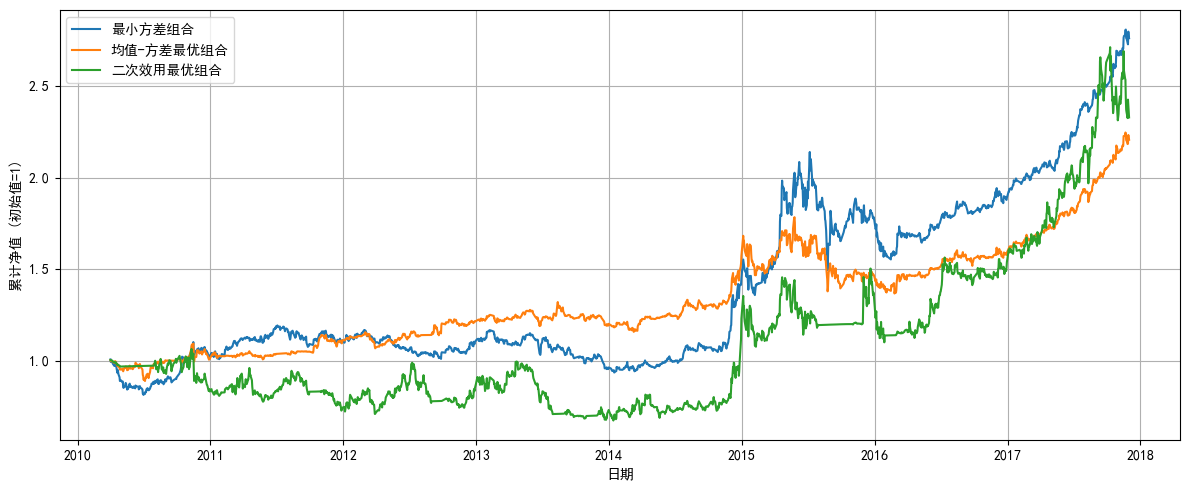

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
for col in strategy_accumulate.columns:
    plt.plot(strategy_accumulate.index,strategy_accumulate[col],label=col)

plt.xlabel("日期")
plt.ylabel("累计净值 (初始值=1)")
plt.grid()
plt.legend(loc="best")
plt.tight_layout()
plt.savefig("Pictures/Hw3_PnL曲线.png")
plt.show()

展示各个月度5个资产权重分配的变化，分析调仓的情况

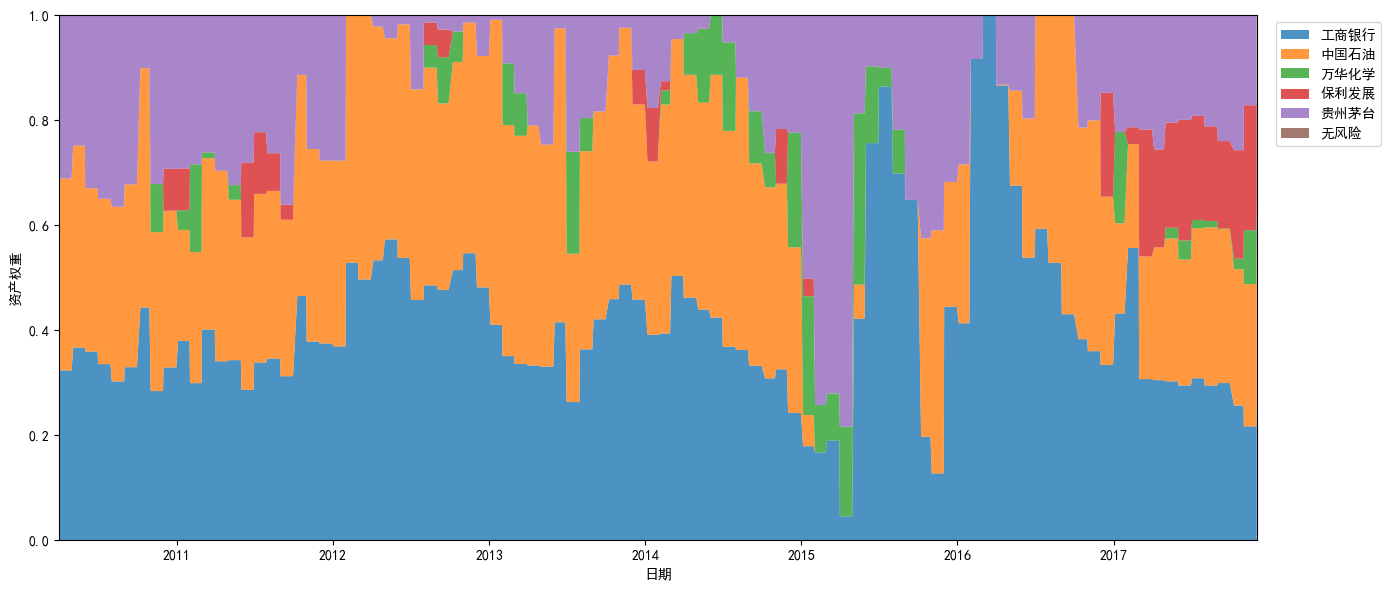

In [11]:
# 全局最小方差组合
plot_w_daily = pd.DataFrame(index=strategy_daily.index,columns=w_min_var.columns,dtype=float)

for i in range(len(last_dates)-1):
    date = last_dates.iloc[i]
    date_next = last_dates.iloc[i+1]
    mask = (strategy_daily.index>date)&(strategy_daily.index<=date_next)
    if not plot_w_daily.loc[mask].empty:
        plot_w_daily.loc[mask] = w_min_var.loc[date].values

plot_w_daily.dropna(inplace=True)


plt.figure(figsize=(14,6))
plt.stackplot(plot_w_daily.index,plot_w_daily.T,labels=plot_w_daily.columns,alpha=0.8)

plt.xlabel("日期")
plt.ylabel("资产权重")
plt.margins(x=0,y=0) 
plt.legend(loc="upper left",bbox_to_anchor=(1.01,1))
plt.tight_layout()
plt.savefig("Pictures/Hw3_min_var_资产权重")
plt.show()

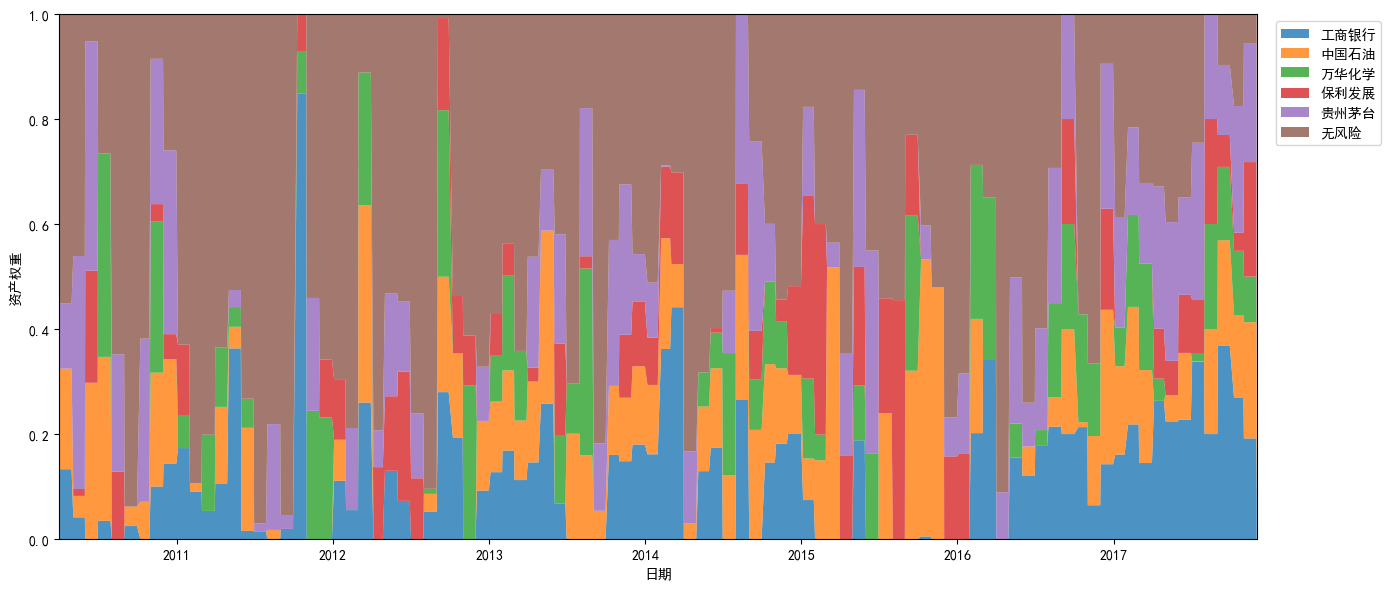

In [12]:
# 均值方差最优组合
plot_w_daily = pd.DataFrame(index=strategy_daily.index,columns=w_best.columns,dtype=float)

for i in range(len(last_dates)-1):
    date = last_dates.iloc[i]
    date_next = last_dates.iloc[i+1]
    mask = (strategy_daily.index>date)&(strategy_daily.index<=date_next)
    if not plot_w_daily.loc[mask].empty:
        plot_w_daily.loc[mask] = w_best.loc[date].values

plot_w_daily.dropna(inplace=True)


plt.figure(figsize=(14,6))
plt.stackplot(plot_w_daily.index, plot_w_daily.T, labels=plot_w_daily.columns,alpha=0.8)

plt.xlabel("日期")
plt.ylabel("资产权重")
plt.margins(x=0,y=0) 
plt.legend(loc="upper left",bbox_to_anchor=(1.01,1))
plt.tight_layout()
plt.savefig("Pictures/Hw3_mv_资产权重")
plt.show()

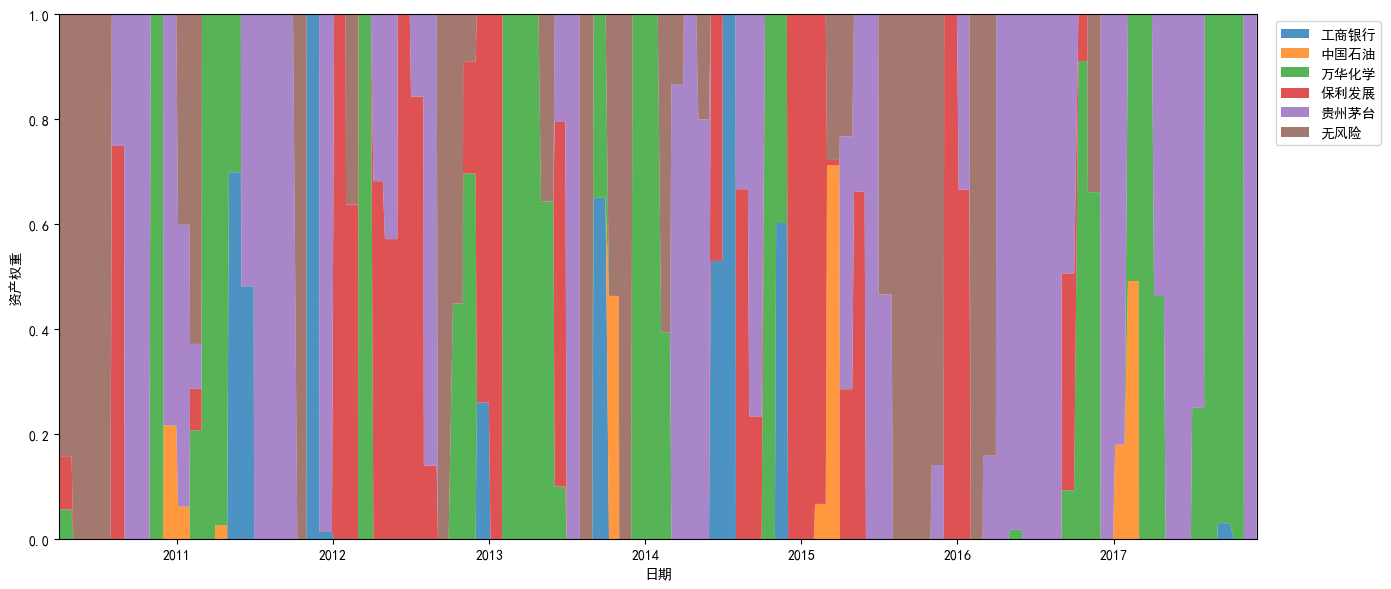

In [13]:
# 二次效用最优组合
plot_w_daily = pd.DataFrame(index=strategy_daily.index,columns=w_utility.columns,dtype=float)

for i in range(len(last_dates)-1):
    date = last_dates.iloc[i]
    date_next = last_dates.iloc[i+1]
    mask = (strategy_daily.index>date)&(strategy_daily.index<=date_next)
    if not plot_w_daily.loc[mask].empty:
        plot_w_daily.loc[mask] = w_utility.loc[date].values

plot_w_daily.dropna(inplace=True)


plt.figure(figsize=(14,6))
plt.stackplot(plot_w_daily.index,plot_w_daily.T,labels=plot_w_daily.columns,alpha=0.8)

plt.xlabel("日期")
plt.ylabel("资产权重")
plt.margins(x=0,y=0) 
plt.legend(loc="upper left",bbox_to_anchor=(1.01,1))
plt.tight_layout()
plt.savefig("Pictures/Hw3_utility_资产权重")
plt.show()

#### 二、用第一次作业的5只股票日收益率、无风险利率和指数的数据：
每只股票50天滚动回归得到β系数，图示β系数的时间序列，简单分析和总结β系数时间序列的特征；展示5只股票β系数排序的变化。

In [14]:
from scipy.stats import linregress

# 市场指数
index_data = pd.read_excel("./Data/市场指数类/沪深300指数日数据.xlsx",na_values=[0])
index_data = index_data[:-2]
index = index_data.copy()
index.set_index("日期", inplace=True)
index = index[["收盘价(元)"]]
index.columns = ["沪深300指数"]
index_ret = index.pct_change().dropna()
index_ret.tail(3)

,沪深300指数
日期,
2022-08-31,0.000748
2022-09-01,-0.008605
2022-09-02,-0.004978


In [15]:
common_dates = stock_ret.index.intersection(index_ret.index).intersection(rf_day.index)
stock_ret_align = stock_ret.loc[common_dates]
index_ret_align = index_ret.loc[common_dates]
rf_day_align = rf_day.loc[common_dates]

stock_excess = stock_ret_align.sub(rf_day_align,axis=0)
market_excess = index_ret_align.sub(rf_day_align,axis=0)

display(stock_excess.tail())
display(market_excess.tail())

,工商银行,中国石油,万华化学,保利发展,贵州茅台
日期,,,,,
2017-11-27,-0.014971,-0.007287,-0.016864,0.001531,-0.014032
2017-11-28,-0.010178,-0.015732,0.015510,-0.023556,0.043217
2017-11-29,-0.000143,0.003511,0.031480,0.100028,-0.015740
2017-11-30,-0.000142,-0.008637,-0.008385,-0.019597,-0.011300
2017-12-01,-0.005209,-0.001365,-0.022999,0.011763,-0.013850


,沪深300指数
日期,
2017-11-27,-0.013362
2017-11-28,0.001305
2017-11-29,-0.000654
2017-11-30,-0.011896
2017-12-01,-0.002128


In [16]:
beta_df = pd.DataFrame(index=stock_excess.index,columns=target_stocks,dtype=float)
r2_current_df = pd.DataFrame(index=stock_excess.index,columns=target_stocks,dtype=float)
r2_prev_df = pd.DataFrame(index=stock_excess.index,columns=target_stocks,dtype=float)

dates = stock_excess.index
mkt_arr = np.ravel(market_excess.values)

for stock in target_stocks:
    stk_arr = np.ravel(stock_excess[stock].values)
    col_idx = beta_df.columns.get_loc(stock)
    
    for i in range(50, len(dates)):
        y_curr = stk_arr[i-49:i+1]
        x_curr = mkt_arr[i-49:i+1]
        y_prev = stk_arr[i-50:i]
        x_prev = mkt_arr[i-50:i]

        slope_c,int_c,r_val_c,_,_ = linregress(x_curr,y_curr)
        beta_df.iloc[i,col_idx] = float(slope_c)
        r2_current_df.iloc[i,col_idx] = float(r_val_c**2)
        
        slope_p,int_p,_,_,_ = linregress(x_prev,y_prev)
        y_pred = int_p+slope_p*x_curr
        ss_res = np.sum((y_curr-y_pred)**2)
        ss_tot = np.sum((y_curr-np.mean(y_curr))**2)
        r2_prev_df.iloc[i,col_idx] = float(1-(ss_res/ss_tot))

beta_df.dropna(inplace=True)
r2_current_df.dropna(inplace=True)
r2_prev_df.dropna(inplace=True)

display(beta_df.head())
display(r2_current_df.head())
display(r2_prev_df.head())

,工商银行,中国石油,万华化学,保利发展,贵州茅台
日期,,,,,
2010-03-23,0.733064,0.662842,0.990849,1.075436,0.459511
2010-03-24,0.731342,0.657105,1.008654,1.077810,0.455206
2010-03-25,0.696199,0.671575,0.947130,1.131165,0.436761
2010-03-26,0.689034,0.677880,0.992815,1.132754,0.450694
2010-03-29,0.702468,0.662366,0.955146,1.141644,0.454470


,工商银行,中国石油,万华化学,保利发展,贵州茅台
日期,,,,,
2010-03-23,0.653688,0.569037,0.280048,0.513649,0.201225
2010-03-24,0.650981,0.570813,0.298627,0.514772,0.198069
2010-03-25,0.625157,0.580957,0.268312,0.546636,0.184031
2010-03-26,0.626156,0.607789,0.298747,0.556523,0.200531
2010-03-29,0.668147,0.654379,0.298293,0.596061,0.216828


,工商银行,中国石油,万华化学,保利发展,贵州茅台
日期,,,,,
2010-03-23,0.653623,0.568243,0.279212,0.511486,0.201106
2010-03-24,0.650530,0.570649,0.296027,0.514723,0.196672
2010-03-25,0.622509,0.580563,0.266401,0.544772,0.183556
2010-03-26,0.625983,0.607179,0.296498,0.556476,0.199704
2010-03-29,0.667708,0.652078,0.297821,0.595367,0.216730


In [17]:
beta_df.describe().round(4)

,工商银行,中国石油,万华化学,保利发展,贵州茅台
count,1870.0000,1870.0000,1870.0000,1870.0000,1870.0000
mean,0.4574,0.5758,1.1437,1.2454,0.6447
std,0.2346,0.2469,0.2652,0.2560,0.2823
min,-0.3257,-0.0738,0.0833,-0.4906,-0.1433
25%,0.3275,0.4249,0.9534,1.0869,0.4599
50%,0.4443,0.5309,1.1440,1.2460,0.6255
75%,0.5514,0.6718,1.2825,1.4399,0.7938
max,1.3028,1.4806,2.1571,1.7591,1.6488


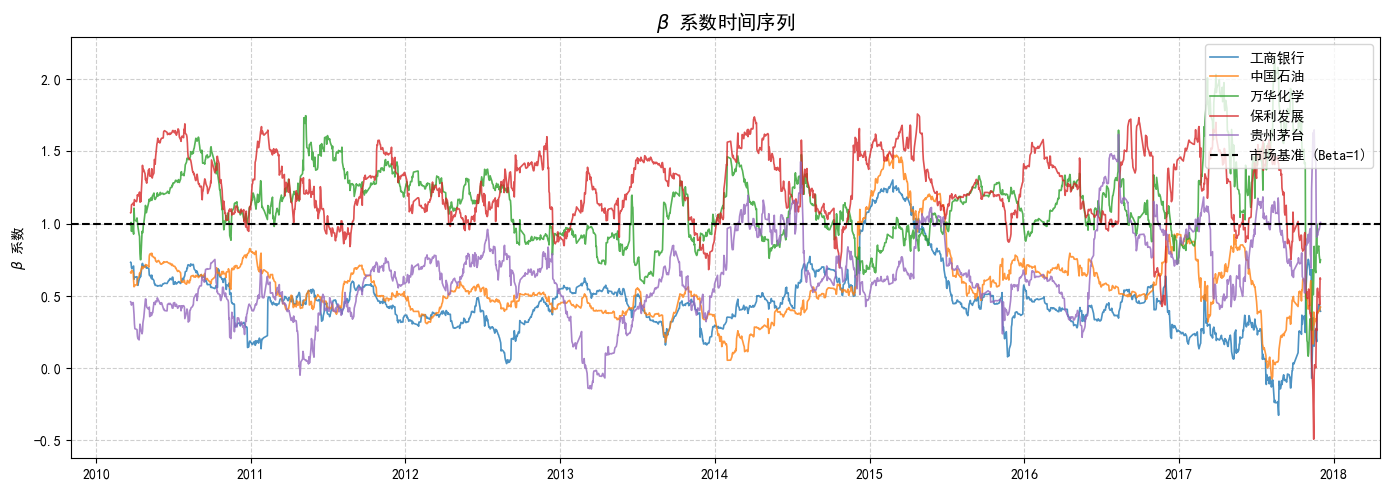

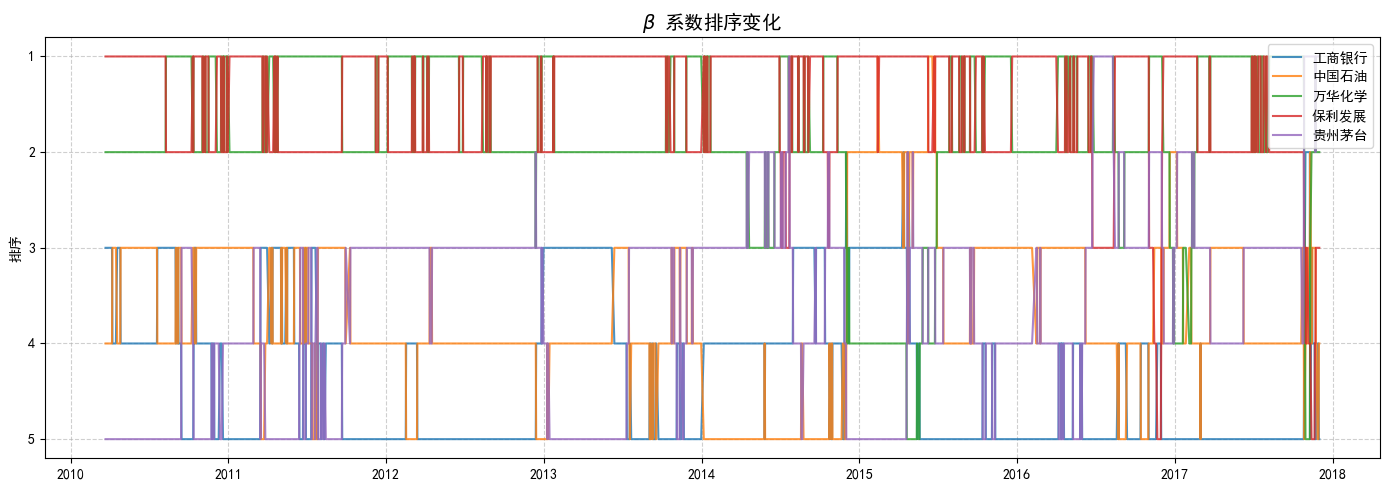

In [18]:
# beta
plt.figure(figsize=(14, 5))

for stock in target_stocks:
    plt.plot(beta_df.index, beta_df[stock], label=stock, linewidth=1.2, alpha=0.8)

plt.axhline(1.0, color="black", linestyle='--', linewidth=1.5, label="市场基准 (Beta=1)")
plt.title(r"$\beta$ 系数时间序列", fontsize=14)
plt.ylabel(r"$\beta$ 系数")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("Pictures/Hw3_beta_series.png")
plt.show()

# beta排序
beta_rank = beta_df.rank(axis=1, ascending=False)

plt.figure(figsize=(14, 5))

for stock in target_stocks:
    plt.plot(beta_rank.index, beta_rank[stock], label=stock, linewidth=1.5, alpha=0.8)

plt.title(r"$\beta$ 系数排序变化", fontsize=14)
plt.ylabel("排序")
plt.gca().invert_yaxis()
plt.yticks([1, 2, 3, 4, 5])
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("Pictures/Hw3_beta_rank.png")
plt.show()

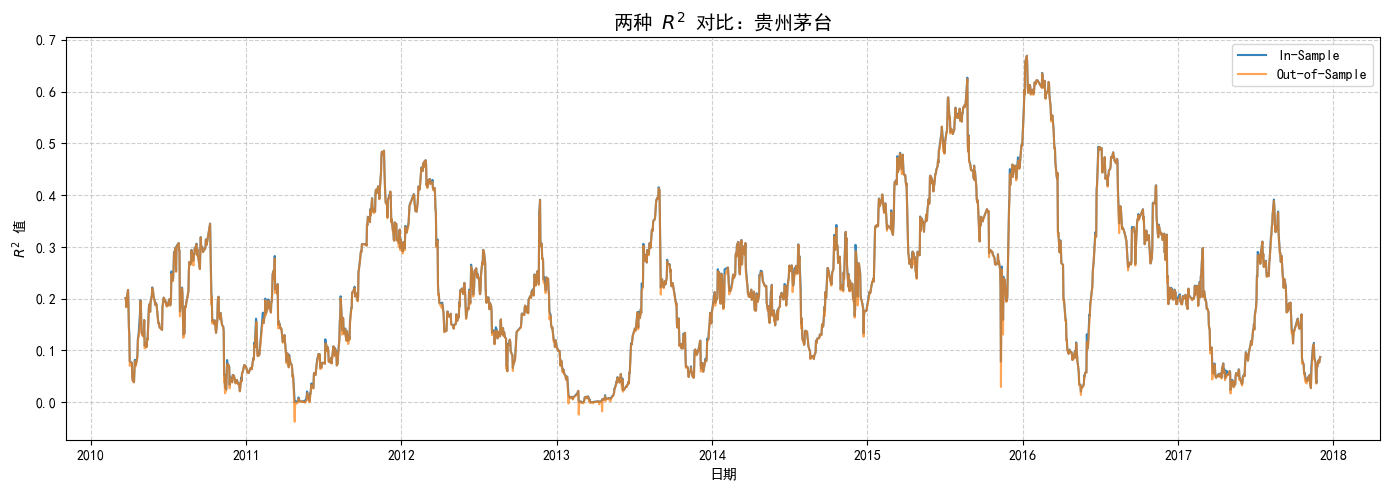

贵州茅台样本内平均 R^2: 0.2275
贵州茅台样本外平均 R^2: 0.2260


In [19]:
example_stock = "贵州茅台"

plt.figure(figsize=(14,5))
plt.plot(r2_current_df.index,r2_current_df[example_stock],label="In-Sample",alpha=0.9)
plt.plot(r2_prev_df.index,r2_prev_df[example_stock],label="Out-of-Sample",alpha=0.7)

plt.title(f"两种 $R^2$ 对比：{example_stock}", fontsize=14)
plt.xlabel("日期")
plt.ylabel("$R^2$ 值")
plt.legend(loc="upper right")
plt.grid(True,linestyle='--',alpha=0.6)
plt.tight_layout()
plt.savefig("Pictures/Hw3_R2.png")
plt.show()

print(f"{example_stock}样本内平均 R^2: {r2_current_df[example_stock].mean():.4f}")
print(f"{example_stock}样本外平均 R^2: {r2_prev_df[example_stock].mean():.4f}")